In [1]:

!uv pip install tensorflow editdistance tf2onnx onnx

Using Python 3.12.12 environment at: /usr
Resolved 40 packages in 544ms
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
⠙ Preparing packages... (0/3)
tf2onnx              ------------------------------     0 B/445.14 KiB
⠙ Preparing packages... (0/3)
tf2onnx              ------------------------------     0 B/445.14 KiB
⠙ Preparing packages... (0/3)
tf2onnx              ------------------------------     0 B/445.14 KiB
⠙ Preparing packages... (0/3)
protobuf             ------------------------------     0 B/158.33 KiB
tf2onnx              ------------------------------     0 B/445.14 KiB
⠙ Preparing packages... (0/3)
protobuf             ------------------------------ 14.83 KiB/158.33 KiB
tf2onnx              ------------------------------     0 B/445.14 KiB
⠙ Preparing packages... (0/3)
protobuf 

In [2]:
import os
import matplotlib.pyplot as plt
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [3]:
# import our model, different layers and activation function 
import tensorflow as tf
import time

from tensorflow.keras.layers import Dense, Dropout, Permute, LSTM, GRU, Reshape, BatchNormalization, Input, Conv2D, MaxPool2D, Lambda, Bidirectional, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.activations import relu, sigmoid, softmax
import tensorflow.keras.backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import CSVLogger, TensorBoard, ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

2026-02-23 06:03:45.390184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771826625.678179      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771826625.761597      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771826626.413797      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771826626.413867      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771826626.413870      17 computation_placer.cc:177] computation placer alr

In [4]:
import json
# open these label jsons files
with open("/kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images/labels.json", 'r', encoding='utf8') as f:
    train_labels = json.load(f)

In [5]:
vietnamese_vowels = [
    "a","à","á","ả","ã","ạ",
    "ă","ằ","ắ","ẳ","ẵ","ặ",
    "â","ầ","ấ","ẩ","ẫ","ậ",

    "e","è","é","ẻ","ẽ","ẹ",
    "ê","ề","ế","ể","ễ","ệ",

    "i","ì","í","ỉ","ĩ","ị",

    "o","ò","ó","ỏ","õ","ọ",
    "ô","ồ","ố","ổ","ỗ","ộ",
    "ơ","ờ","ớ","ở","ỡ","ợ",

    "u","ù","ú","ủ","ũ","ụ",
    "ư","ừ","ứ","ử","ữ","ự",

    "y","ỳ","ý","ỷ","ỹ","ỵ"
]

vietnamese_consonants = [
    "b","c","d","đ","g","h","k","l","m",
    "n","p","q","r","s","t","v","x"
]

# Uppercase
vietnamese_vowels_upper = [c.upper() for c in vietnamese_vowels]
vietnamese_consonants_upper = [c.upper() for c in vietnamese_consonants]

digits = list("0123456789")

punctuation = [
    " ", ".", ",", ":", ";",
    "!", "?", "-", "_",
    "(", ")", "[", "]",
    "\"", "'", "/",

    # ✅ ADD MISSING SYMBOLS
    "%", "&", "*", "=", "@", "$"
]

# FINAL char_list
char_list = (
    vietnamese_vowels
    + vietnamese_consonants
    + vietnamese_vowels_upper
    + vietnamese_consonants_upper
    + digits
    + punctuation
)

extra_chars = [
    "f","j","w","z",
    "F","J","W","Z",
    "#","+",
]

# deduplicate + sort
char_list = sorted(set(char_list + extra_chars))

# rebuild index
char_to_idx = {c: i for i, c in enumerate(char_list)}

print("Total characters:", len(char_list))

Total characters: 220


In [6]:
def encode_to_labels(txt):
    # encoding each output word into digits of indexes
    dig_lst = []
    for index, char in enumerate(txt):
        try:
            dig_lst.append(char_list.index(char))
        except:
            print("No found in char_list :", char)
        
    return dig_lst

In [7]:
inputs = Input(shape=(96, None, 1), name="input_image")

# =========================
# CNN FEATURE EXTRACTOR
# =========================

# Block 1
x = Conv2D(64, (3,3), padding="same")(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(3,2))(x)   # H/2, W/2

# Block 2
x = Conv2D(128, (3,3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(2,2))(x)   # H/4, W/4

# Block 3
x = Conv2D(256, (3,3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)
x = MaxPool2D(pool_size=(2,1))(x)   # H/8, W/4

# Block 4 (diacritic-preserving)
x = Conv2D(256, (3,3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.2)(x)
x = MaxPool2D(pool_size=(2,1))(x)   # H/16, W/4

# Final CNN block
x = Conv2D(512, (3,3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

# =========================
# HEIGHT REDUCTION (SAFE)
# =========================
# Now height ≈ 96 / 16 = 6
# Reduce to 2, not 1
x = MaxPool2D(pool_size=(3,1))(x)   # H ≈ 2

# =========================
# CNN → RNN
# =========================
x = Lambda(
    lambda t: tf.reshape(
        t,
        [tf.shape(t)[0], tf.shape(t)[2], tf.shape(t)[1] * tf.shape(t)[3]]
    )
)(x)

# =========================
# SEQUENCE MODELING
# =========================
x = Bidirectional(
    LSTM(256, return_sequences=True, dropout=0.25)
)(x)

x = Bidirectional(
    LSTM(256, return_sequences=True, dropout=0.25)
)(x)

# =========================
# OUTPUT
# =========================
outputs = Dense(len(char_list) + 1, activation="softmax")(x)

act_model = Model(inputs, outputs)
act_model.summary()

2026-02-23 06:04:04.759015: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 96, None, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, None, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, None, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, None, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, None, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, None, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, None, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, None, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, None, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, None, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, None, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, None, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, None, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, None, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, None, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, None, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, None, 512)   │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, None, 512)   │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 4, None, 512)   │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,407,965 (20.63 MB)

 Trainable params: 5,405,533 (20.62 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [8]:
act_model.load_weights('/kaggle/input/datasets/huyyuh/ocrweight/checkpoint.weights.h5')

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path, target_height=96, debug=False):
    # ======================
    # READ IMAGE
    # ======================
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not found")

    h, w = img.shape

    # ======================
    # RESIZE (KEEP ASPECT)
    # ======================
    scale = target_height / h
    new_w = int(w * scale)
    img = cv2.resize(img, (new_w, target_height))

    # ======================
    # SHADOW REMOVAL
    # ======================
    background = cv2.medianBlur(img, 31)
    img = cv2.divide(img, background, scale=255)

    if debug:
        plt.imshow(img, cmap='gray')
        plt.title('Shadow Removed')
        plt.show()

    # ======================
    # 90% INTENSITY FILTER
    # ======================
    max_val = np.max(img)
    img = np.where(img >= 0.9 * max_val, 255, img).astype(np.uint8)

    if debug:
        plt.imshow(img, cmap='gray')
        plt.title('90% Intensity Filter')
        plt.show()

    # ======================
    # CLAHE
    # ======================
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    if debug:
        plt.imshow(img, cmap='gray')
        plt.title('CLAHE')
        plt.show()

    # ======================
    # ADAPTIVE THRESHOLD
    # ======================
    bw = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        10
    )

    if debug:
        plt.imshow(bw, cmap='gray')
        plt.title('Adaptive Threshold')
        plt.show()

    # ======================
    # REMOVE ISOLATED PIXELS
    # ======================
    bw_bin = (bw > 0).astype(np.uint8)

    neighbor_count = cv2.filter2D(
        bw_bin,
        -1,
        np.ones((3, 3), np.uint8)
    )

    # A pixel is isolated if it is white but has <=1 total neighbors
    isolated = (bw_bin == 1) & (neighbor_count <= 2)

    clean = bw.copy()
    clean[isolated] = 0

    if debug:
        plt.imshow(clean, cmap='gray')
        plt.title('Neighbor Clean')
        plt.show()

    # ======================
    # NORMALIZE FOR CRNN
    # ======================
    clean = clean.astype(np.float32) / 255.0
    clean = np.expand_dims(clean, axis=-1)
    clean = np.expand_dims(clean, axis=0)

    return clean

In [10]:
import cv2
import numpy as np

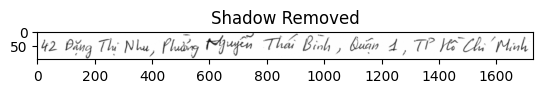

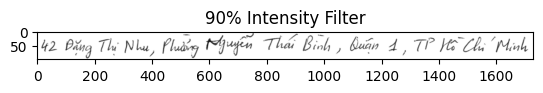

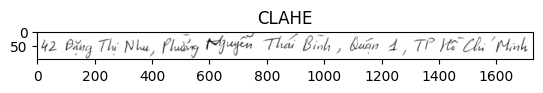

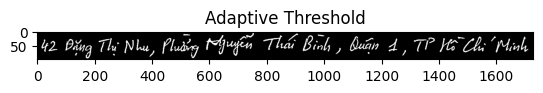

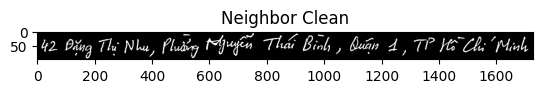

(1, 96, 1729, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 432, 221)


In [11]:
img = preprocess_image("/kaggle/input/datasets/huyyuh/3500-w/vn_handwritten_images/data/0003_samples.png", debug = True)
print(img.shape)
pred = act_model.predict(img)
print(pred.shape)   # (1, T, num_classes)


In [12]:
input_length = np.ones(pred.shape[0]) * pred.shape[1]

decoded, _ = K.ctc_decode(
    pred,
    input_length=input_length,
    greedy=True
)

decoded = K.get_value(decoded[0])

In [13]:
blank_idx = len(char_list)

def decode_text(seq):
    text = ""
    for p in seq:
        if p != -1 and p != blank_idx:
            text += char_list[p]
    return text

text = decode_text(decoded[0])
print("Predicted text:", text)


Predicted text: 42 Đặng Thị Nhu, Phường Nguyễn Thái Bình, Quận 1, TP Hồ Chí Minh 


In [14]:
import matplotlib.pyplot as plt

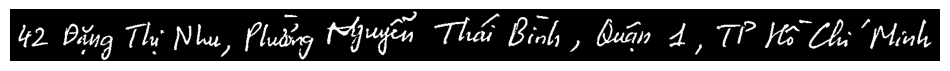

In [15]:
plt.figure(figsize=(12, 3))
plt.imshow(img[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

In [16]:
runs = 100
start = time.time()

for _ in range(runs):
    _ = act_model.predict(img)

end = time.time()
avg_time = (end - start) / runs

print(f"TF inference time: {avg_time*1000:.2f} ms")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [17]:
import tf2onnx
# Define input signature (MATCH your inference model input)

spec = (tf.TensorSpec(
    (None, 96, None, 1),  # <-- adjust if needed
    tf.float32,
    name="input"
),)

# Convert
onnx_model, _ = tf2onnx.convert.from_keras(
    act_model,
    input_signature=spec,
    opset=13,
    output_path="/kaggle/working/crnn_inference.onnx"
)

print("ONNX model saved!")


I0000 00:00:1771826704.743003      17 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1771826704.743269      17 single_machine.cc:374] Starting new session
I0000 00:00:1771826705.703034      17 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1771826705.703363      17 single_machine.cc:374] Starting new session
TF freezing failed. Attempting to fix freezing errors.
Removed BiasAdd functional_1/bidirectional_1_2/backward_lstm_1_1/AssignVariableOp
Removed FloorMod functional_1/bidirectional_1_2/forward_lstm_1_1/AssignVariableOp
Removed FloorMod functional_1/bidirectional_1/backward_lstm_1/AssignVariableOp
Removed FloorMod functional_1/bidirectional_1/forward_lstm_1/AssignVariableOp
I0000 00:00:1771826706.267988      17 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00:1771826706.268288      17 single_machine.cc:374] Starting new session
I00

ONNX model saved!


In [18]:
import onnx

model = onnx.load("/kaggle/working/crnn_inference.onnx")
onnx.checker.check_model(model)
print("ONNX model is valid!")


ONNX model is valid!


In [19]:
!uv pip install onnxruntime

Using Python 3.12.12 environment at: /usr
Resolved 7 packages in 165ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
Prepared 1 package in 358ms
Installed 1 package in 11ms
 + onnxruntime==1.24.2


In [20]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("/kaggle/working/crnn_inference.onnx", providers=["CPUExecutionProvider"])

input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

pred = sess.run(
    [output_name],
    {input_name: img.astype(np.float32)}
)[0]

print(pred.shape)  # (1, T, num_classes)


(1, 432, 221)


In [21]:
blank_idx = len(char_list)

def ctc_greedy_decode(pred):
    # pred: (T, num_classes)
    best_path = np.argmax(pred, axis=-1)

    text = []
    prev = -1
    for p in best_path:
        if p != prev and p != blank_idx:
            text.append(char_list[p])
        prev = p
    return "".join(text)

text = ctc_greedy_decode(pred[0])
print("Predicted text:", text)


Predicted text: 42 Đặng Thị Nhu, Phường Nguyễn Thái Bình, Quận 1, TP Hồ Chí Minh 


In [22]:
import onnxruntime as ort

sess = ort.InferenceSession("/kaggle/working/crnn_inference.onnx", providers=["CPUExecutionProvider"])

input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# warm-up
for _ in range(10):
    sess.run([output_name], {input_name: img})

# measure
runs = 100
start = time.time()

for _ in range(runs):
    _ = sess.run([output_name], {input_name: img})

end = time.time()
avg_time = (end - start) / runs

print(f"ONNX inference time: {avg_time*1000:.2f} ms")


ONNX inference time: 298.23 ms
